Lean data ready for Keras. Total engineered features: 12
Model compiled successfully on CPU!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

Starting training...
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6000 - auc: 0.6163 - loss: 0.6899 - val_accuracy: 0.7188 - val_auc: 0.7922 - val_loss: 0.7662
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5680 - auc: 0.6009 - loss: 0.7055 - val_accuracy: 0.7500 - val_auc: 0.7922 - val_loss: 0.7324
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6960 - auc: 0.7107 - loss: 0.6331 - val_accuracy: 0.6875 - val_auc: 0.7863 - val_loss: 0.6948
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6240 - auc: 0.6646 - loss: 0.6463 - val_accuracy: 0.6562 - val_auc: 0.7784 - val_loss: 0.6630
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6720 - auc: 0.7582 - loss: 0.5808 - val_accuracy: 0.7188 - val_auc: 0.7843 - val_loss: 0.6320
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6400 - auc: 0.7197 - loss: 0.5993 - val_accuracy: 0.7188 - val_auc: 0.7980 - val_loss: 0.6126
Epoch 7/150
4/4 ━━━━━━━━━━━━━━

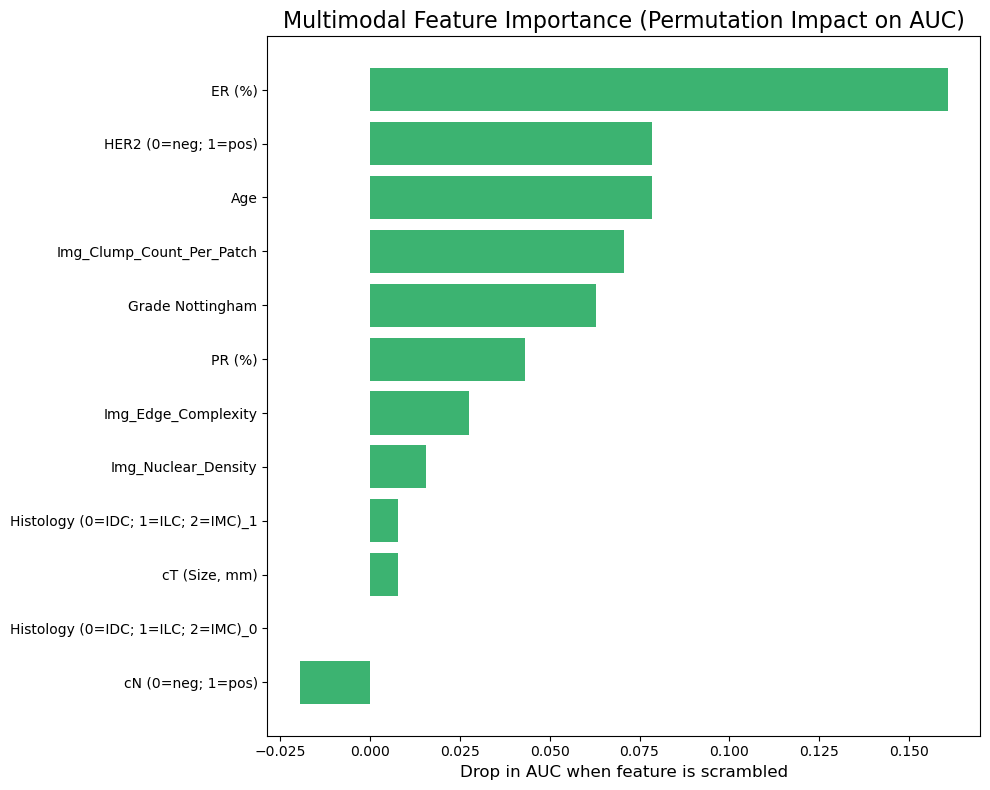

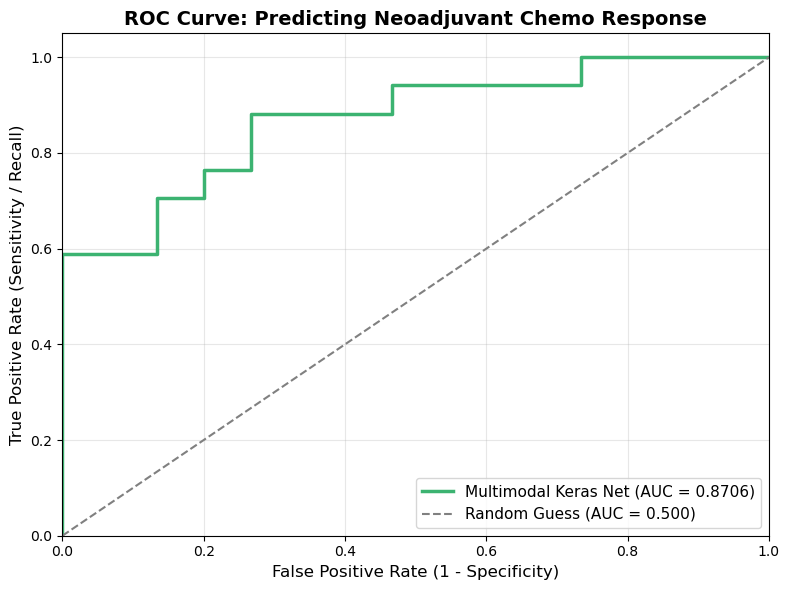


 CLINICAL CLASSIFICATION METRICS (Threshold = 0.5)
                       precision    recall  f1-score   support

 Partial Response (0)       0.68      1.00      0.81        15
Complete Response (1)       1.00      0.59      0.74        17

             accuracy                           0.78        32
            macro avg       0.84      0.79      0.78        32
         weighted avg       0.85      0.78      0.77        32



In [5]:
import os
# 1. Put a blindfold on TensorFlow so it ignores the broken GPU entirely
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" 
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf
from tensorflow.keras import layers, models, metrics, callbacks

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Load merged clinical + image features (run feature_extr notebook first to generate CSV)
import os
_data_path = '../data/full_img_extract.csv'
if os.path.exists(_data_path):
    df = pd.read_csv(_data_path)
else:
    df = pd.read_excel('../data/full_img_extract.xlsx')

X = df.drop("NAC Response (0=complete; 1=partial)", axis=1)
y = df["NAC Response (0=complete; 1=partial)"]

# The continuous numerical drivers + your 3 independent biomarkers
NUM_FEATURES = [
    'Age', 
    'cT (Size, mm)', 
    'ER (%)', 
    'PR (%)', 
    'Img_Nuclear_Density',        
    'Img_Edge_Complexity',        
    'Img_Clump_Count_Per_Patch'   #the other biomarkers were multicollinear
]

# The top binary drivers
BINARY_FEATURES = [
    'HER2 (0=neg; 1=pos)', 
    'cN (0=neg; 1=pos)'
]

# The top ordinal driver
ORDINAL_FEATURES = [
    'Grade Nottingham'
]

# The top categorical driver
CAT_FEATURES = [
    'Histology (0=IDC; 1=ILC; 2=IMC)'
]
#leave out surgery vars as those are post NAC and are therefore, data leakage

df[NUM_FEATURES].corr()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                   
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)) 
])

bin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM_FEATURES),
        ('cat', cat_pipeline, CAT_FEATURES),
        ('ord', ord_pipeline, ORDINAL_FEATURES),
        ('bin', bin_pipeline, BINARY_FEATURES)
    ],
    remainder='drop' # Automatically purges all the noise not in these lists
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

total_features = X_train_processed.shape[1]
print(f"Lean data ready for Keras. Total engineered features: {total_features}")

model = models.Sequential([
    layers.Input(shape=(total_features,)), 
    
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4), 
    
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', metrics.AUC(name='auc')]
)

print("Model compiled successfully on CPU!")
model.summary()

early_stopping = callbacks.EarlyStopping(
    monitor='val_auc', 
    mode='max', 
    patience=15, 
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_train_processed, 
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=150, 
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_accuracy, test_auc = model.evaluate(X_test_processed, y_test, verbose=0)

print(" FINAL MULTIMODAL MODEL PERFORMANCE")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC:      {test_auc:.4f}")


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
np.random.seed(42)

# 1. Extract Feature Names from your Scikit-Learn Pipeline
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_names = cat_encoder.get_feature_names_out(CAT_FEATURES)

# Combine all names in the exact order they were fed into the ColumnTransformer
feature_names = NUM_FEATURES + list(cat_names) + ORDINAL_FEATURES + BINARY_FEATURES

# 2. Calculate Baseline AUC
baseline_preds = model.predict(X_test_processed, verbose=0).flatten()
baseline_auc = roc_auc_score(y_test, baseline_preds)

# 3. Calculate Permutation Importance (How much AUC drops when a feature is scrambled)
importances = []

for i in range(X_test_processed.shape[1]):
    # Copy the test set so we don't permanently alter the original data
    X_test_shuffled = X_test_processed.copy()
    
    # Scramble only the i-th column
    np.random.shuffle(X_test_shuffled[:, i])
    
    # Predict with the scrambled data
    shuffled_preds = model.predict(X_test_shuffled, verbose=0).flatten()
    shuffled_auc = roc_auc_score(y_test, shuffled_preds)
    
    # The importance is the drop in AUC
    drop_in_auc = baseline_auc - shuffled_auc
    importances.append(drop_in_auc)

importances = np.array(importances)

# 4. Generate the Plot
# Sort features by importance (ascending order for the horizontal bar chart)
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title("Multimodal Feature Importance (Permutation Impact on AUC)", fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Drop in AUC when feature is scrambled", fontsize=12)
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report

# 1. Get Model Predictions
# For ROC, we need the raw probabilities (0.0 to 1.0)
y_pred_probs = model.predict(X_test_processed, verbose=0).flatten()

# For Precision/Recall/F1, we need hard class labels (0 or 1)
# We use a standard 0.5 threshold here
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# 2. Calculate ROC Curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr) # This will match your 0.8549

# 3. Generate the ROC Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='mediumseagreen', lw=2.5, label=f'Multimodal Keras Net (AUC = {roc_auc:.4f})')

# Optional: Add your teammates' baseline to the chart to visualize the win!
# Just plot a single point or a rough curve if you have their probabilities, 
# otherwise just keep this line to show the 0.5 random-guess baseline:
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve: Predicting Neoadjuvant Chemo Response', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Print the Clinical Metrics
print("\n" + "="*50)
print(" CLINICAL CLASSIFICATION METRICS (Threshold = 0.5)")
print("="*50)
# Make sure target_names match how your 0 and 1 are defined! 
# Assuming 0 = Partial Response, 1 = Complete Response (pCR)
print(classification_report(y_test, y_pred_classes, target_names=['Partial Response (0)', 'Complete Response (1)']))

In [6]:

import pickle

data_to_save = {'model': model, 'processor': preprocessor}
with open('../models/artifacts.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)